#### LOGISTIC REGRESSION

#### 1. Data Exploration

a. Load Dataset

In [8]:
import pandas as pd
df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\titanic_model.pkl.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


b. Check Features & Summary

In [9]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

c. Visualizations

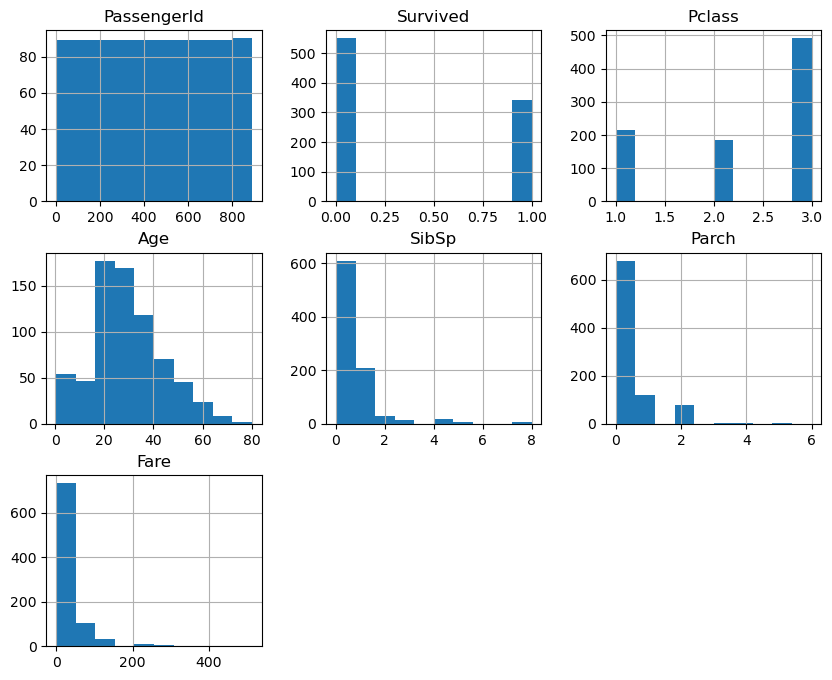

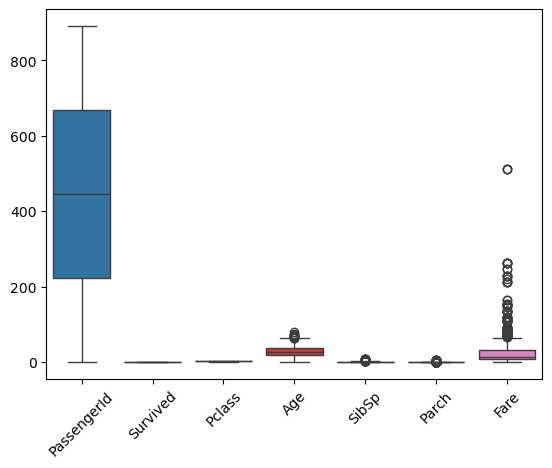

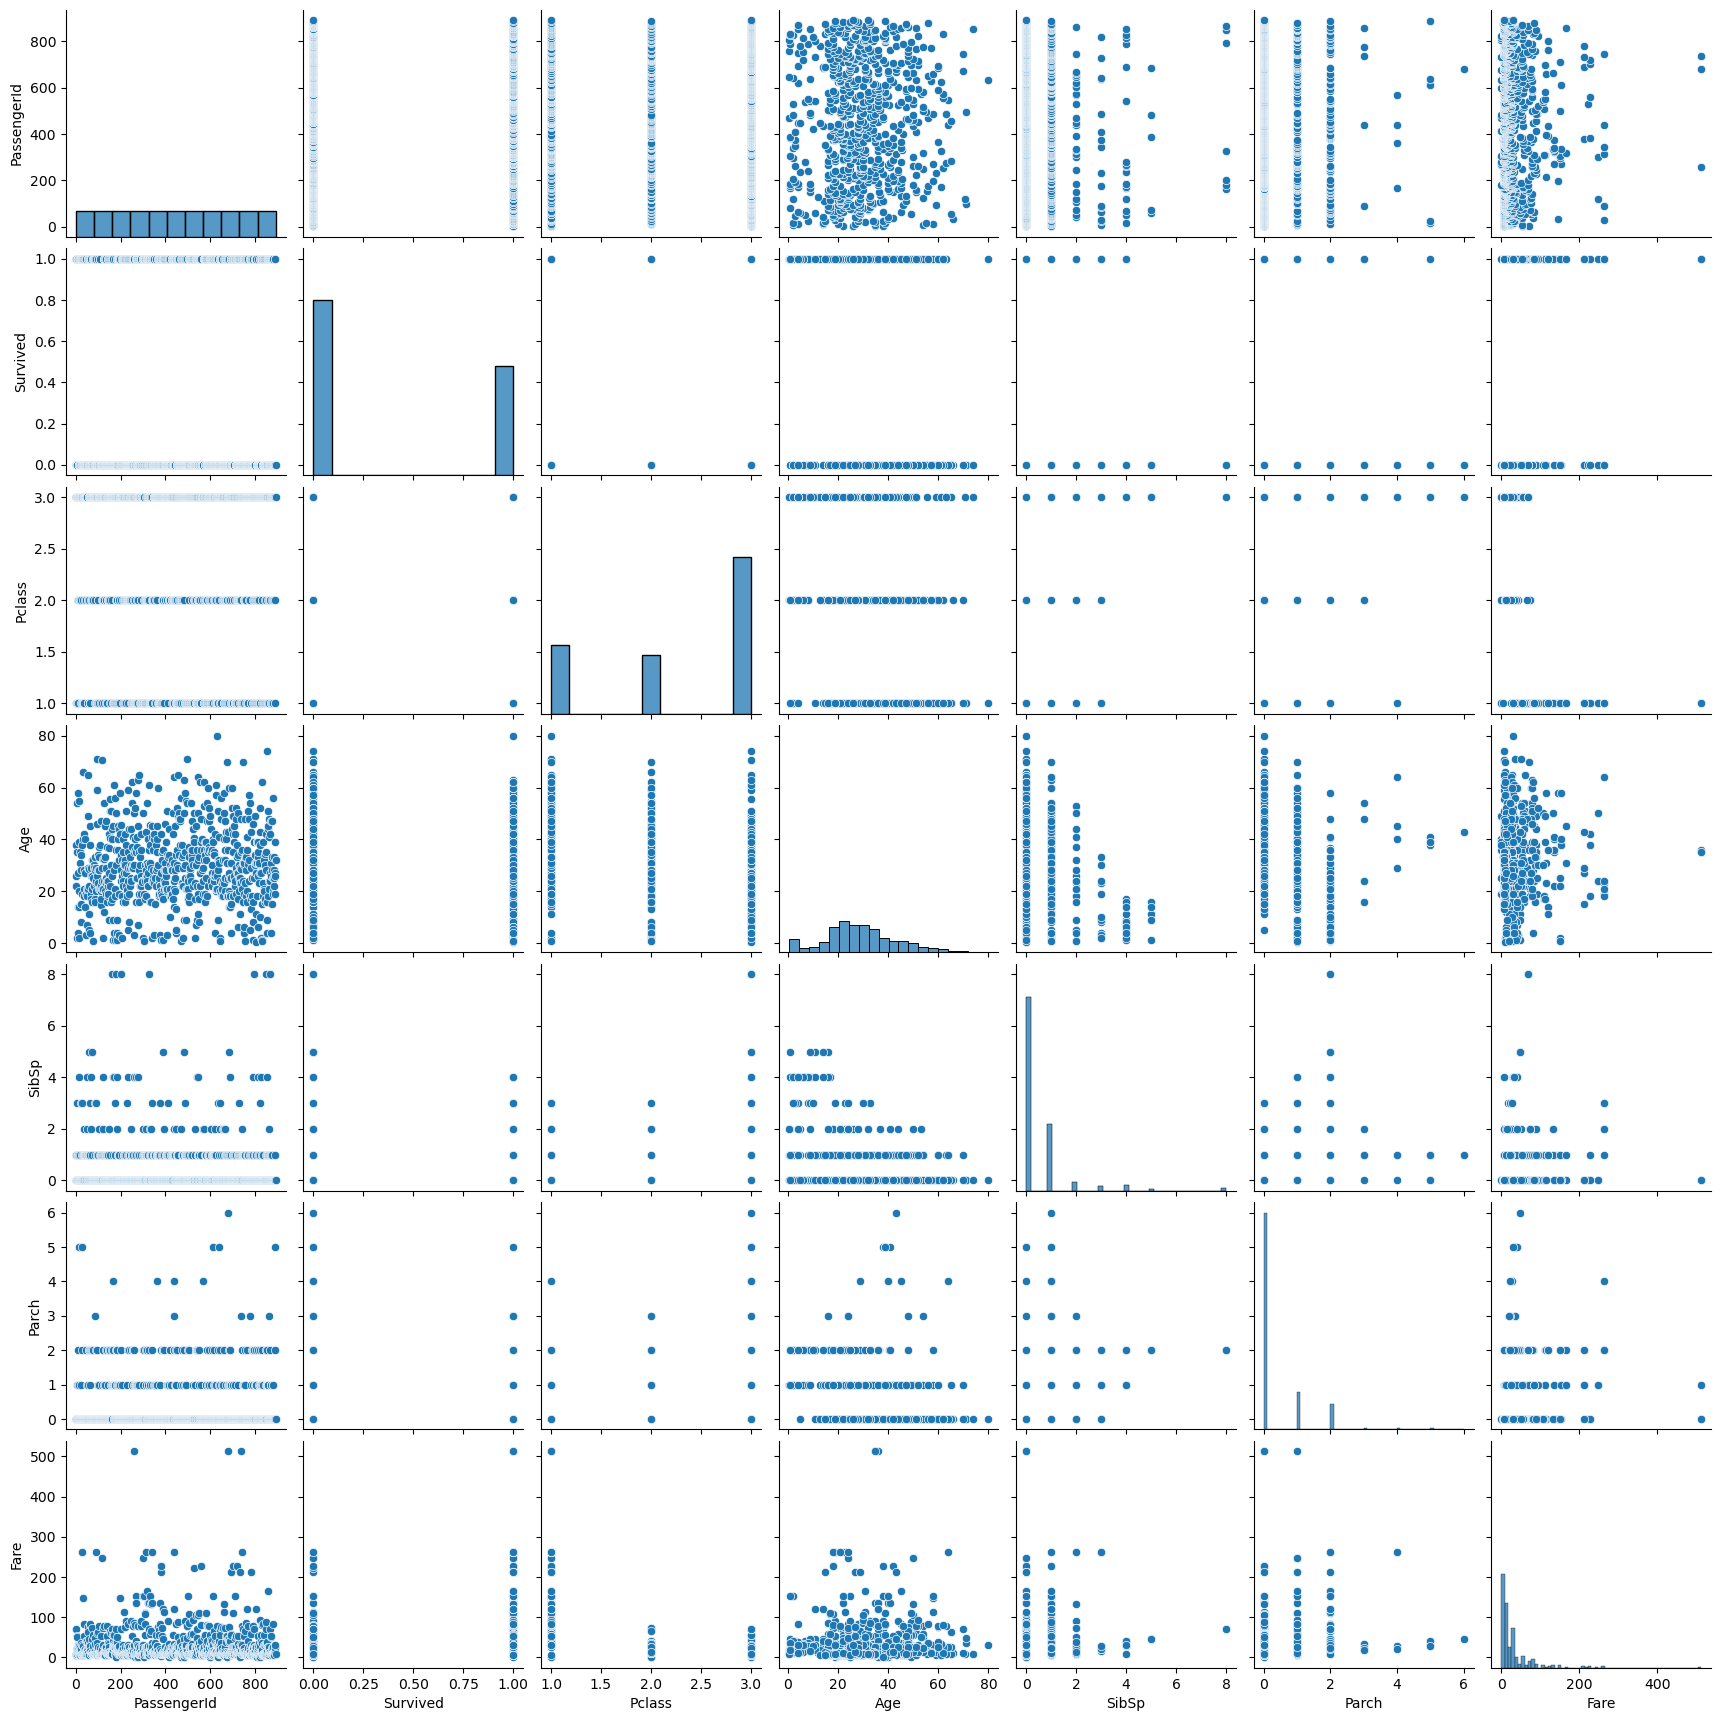

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Histogram
df.hist(figsize=(10,8))
plt.show()

# Boxplot
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

# Pairplot
sns.pairplot(df)
plt.show()

#### 2.Data Preprocessing

a. Handle Missing Values

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] =df['Embarked'].fillna(df['Embarked'].mode()[0])

b. Encode Categorical Data

In [12]:
df = pd.get_dummies(df, drop_first=True)

3. Model Building

a. Split Data

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

b. Train Logistic Regression Model

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


4. Model Evaluation

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8379888268156425
Precision: 0.8727272727272727
Recall: 0.6857142857142857
F1 Score: 0.768


ROC Curve

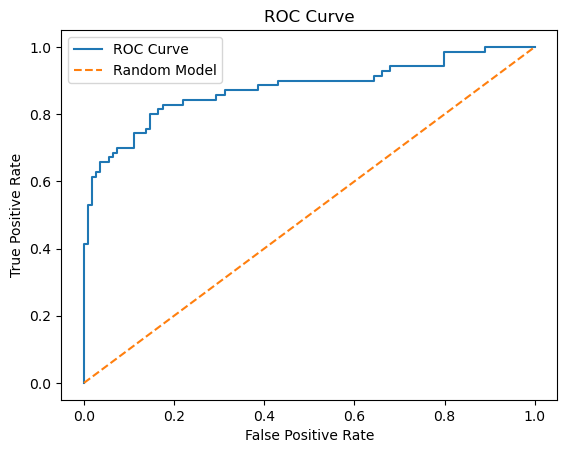

ROC-AUC: 0.8766710353866317


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities for positive class
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Model")  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# AUC Score
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

5. Interpretation

a. Coefficients

In [17]:
coefficients = pd.DataFrame(model.coef_.T, index=X.columns, columns=["Coefficient"])
print(coefficients)

             Coefficient
PassengerId    -0.000078
Pclass         -1.071747
Age            -0.035103
SibSp          -0.275480
Parch          -0.085353
...                  ...
Cabin_F4        0.113543
Cabin_G6       -0.219642
Cabin_T        -0.201676
Embarked_Q      0.265177
Embarked_S     -0.350804

[1725 rows x 1 columns]


6. Deployment with Streamlit

In [18]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


Create app.py

In [19]:
import streamlit as st
import pickle
import numpy as np

# Load model

model = pickle.load(open("titanic_model.pkl", "rb"))
st.title("Titanic Survival Prediction")

# Inputs
pclass = st.selectbox("Pclass", [1, 2, 3])
sex = st.selectbox("Sex (0 = Female, 1 = Male)", [0, 1])
age = st.number_input("Age", min_value=0.0)
fare = st.number_input("Fare", min_value=0.0)

# Prediction
if st.button("Predict"):
    data = np.array([[pclass, sex, age, fare]])
    prediction = model.predict(data)

    if prediction[0] == 1:
        st.success("Survived")
    else:
        st.error("Not Survived")

2026-04-03 12:01:12.895 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:01:12.896 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:01:12.896 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:01:12.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:01:12.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:01:12.899 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:01:12.900 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:01:12.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [20]:
import streamlit as st
import pickle
import numpy as np

# Load model safely
try:
    model = pickle.load(open("titanic_model.pkl", "rb"))
except:
    st.error("Model file not found! Make sure 'titanic_model.pkl' is in the same folder.")
    st.stop()

st.title("Titanic Survival Prediction")

# Inputs
pclass = st.selectbox("Pclass", [1, 2, 3])
sex = st.selectbox("Sex", ["Female", "Male"])
sex = 0 if sex == "Female" else 1

age = st.number_input("Age", min_value=0.0)
fare = st.number_input("Fare", min_value=0.0)

# Prediction
if st.button("Predict"):
    data = np.array([[pclass, sex, age, fare]])
    
    prediction = model.predict(data)[0]
    prob = model.predict_proba(data)[0][1]

    if prediction == 1:
        st.success(f"Survived ✅ (Probability: {prob:.2f})")
    else:
        st.error(f"Not Survived ❌ (Probability: {prob:.2f})")

2026-04-03 12:06:28.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:06:28.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:06:28.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:06:28.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:06:28.855 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:06:28.855 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:06:28.856 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 12:06:28.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar